<a href="https://colab.research.google.com/github/biggmanuel/Vanguard-CNN/blob/main/cnn_social_engineering_model_h5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import pickle
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from sklearn.model_selection import train_test_split

print("TensorFlow Version:", tf.__version__)

# ---------------------------------------------------------
# 1. LOAD THE REAL DATASET FROM GITHUB
# ---------------------------------------------------------
print("\nLoading dataset dynamically from cloud...")
# Fetching the dataset directly from the Vanguard-CNN GitHub repository
dataset_url = 'https://github.com/biggmanuel/Vanguard-CNN/raw/refs/heads/main/spam.csv'
df = pd.read_csv(dataset_url, encoding='latin-1')

# The dataset has extra empty columns. We only want v1 (label) and v2 (text)
df = df[['v1', 'v2']]
df.columns = ['label', 'text']

# Neural networks only understand numbers. Map 'ham' (safe) to 0, and 'spam' (threat) to 1.
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(f"Dataset loaded successfully! Total records: {len(df)}")

# ---------------------------------------------------------
# 2. PREPROCESSING
# ---------------------------------------------------------
texts = df['text'].values
labels = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)

vocab_size = 5000
max_length = 50

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

# ---------------------------------------------------------
# 3. BUILD THE CNN
# ---------------------------------------------------------
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# ---------------------------------------------------------
# 4. TRAIN THE MODEL
# ---------------------------------------------------------
print("\n--- Starting Training Process on 5,000+ Records ---")
history = model.fit(
    X_train_padded, y_train,
    epochs=5,
    validation_data=(X_test_padded, y_test),
    verbose=1
)

# ---------------------------------------------------------
# 5. SAVE THE ARTIFACTS
# ---------------------------------------------------------
model.save('cnn_social_engineering_model.h5')
print("\nModel successfully trained and saved as 'cnn_social_engineering_model.h5'")

with open('tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("Tokenizer successfully saved as 'tokenizer.pkl'")

TensorFlow Version: 2.20.0

Loading dataset dynamically from cloud...
Dataset loaded successfully! Total records: 5572

--- Starting Training Process on 5,000+ Records ---
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8901 - loss: 0.3208 - val_accuracy: 0.9821 - val_loss: 0.0764
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9874 - loss: 0.0462 - val_accuracy: 0.9821 - val_loss: 0.0516
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9957 - loss: 0.0136 - val_accuracy: 0.9874 - val_loss: 0.0546
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9980 - loss: 0.0064 - val_accuracy: 0.9857 - val_loss: 0.0676
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.9857 - val_loss: 0.0699



Model successfully trained and saved as 'cnn_social_engineering_model.h5'
Tokenizer successfully saved as 'tokenizer.pkl'


In [ ]:
!pip install fastapi uvicorn nest-asyncio pydantic
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [ ]:
%%writefile main.py
from fastapi import FastAPI
from pydantic import BaseModel
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle
from fastapi.middleware.cors import CORSMiddleware

app = FastAPI()

# Allow our future frontend to talk to this API
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# Load the Brain and Tokenizer
model = tf.keras.models.load_model('cnn_social_engineering_model.h5')
with open('tokenizer.pkl', 'rb') as handle:
    tokenizer = pickle.load(handle)

MAX_LENGTH = 50
THRESHOLD = 0.85

class Payload(BaseModel):
    text: str

@app.post("/analyze")
async def analyze_text(payload: Payload):
    # Preprocess incoming text
    sequence = tokenizer.texts_to_sequences([payload.text])
    padded_sequence = pad_sequences(sequence, maxlen=MAX_LENGTH, padding='post', truncating='post')

    # Predict
    prediction = model.predict(padded_sequence)
    score = float(prediction[0][0])

    return {
        "raw_text": payload.text,
        "threat_score": round(score, 4),
        "is_threat": score >= THRESHOLD
    }

Writing main.py


In [ ]:
import urllib.request
import nest_asyncio
import uvicorn
import threading
import subprocess
import requests
import time

# 1. Get your LocalTunnel password
endpoint_ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip()
print(f"*** YOUR LOCALTUNNEL PASSWORD IS: {endpoint_ip} ***\n")

# 2. Run the FastAPI server in the background
def run_app():
    nest_asyncio.apply()
    uvicorn.run("main:app", host="0.0.0.0", port=8000, log_level="critical")

thread = threading.Thread(target=run_app, daemon=True)
thread.start()

# 3. Start Localtunnel and capture the generated URL
print("Starting Localtunnel and waiting for URL...")
process = subprocess.Popen(["npx", "localtunnel", "--port", "8000"], stdout=subprocess.PIPE)

tunnel_url = ""
for line in iter(process.stdout.readline, b''):
    output = line.decode("utf-8").strip()
    if "your url is:" in output:
        tunnel_url = output.split("your url is:")[1].strip()
        print(f"Active API URL: {tunnel_url}")
        break

# 4. Push the new URL directly to Firebase Database
firebase_db_url = "https://cnn-zeroday-engine-default-rtdb.firebaseio.com/config.json"

if tunnel_url:
    print("Pushing URL to Firebase...")
    response = requests.put(firebase_db_url, json={"api_url": tunnel_url})
    if response.status_code == 200:
        print("✅ SUCCESS! Firebase updated. Your web dashboard is now permanently linked!")
    else:
        print(f"❌ Failed to update Firebase. Code: {response.status_code}")
        print(f"Firebase Error Message: {response.text}")

*** YOUR LOCALTUNNEL PASSWORD IS: 34.86.17.83 ***

Starting Localtunnel and waiting for URL...


Active API URL: https://dry-beers-spend.loca.lt
Pushing URL to Firebase...
✅ SUCCESS! Firebase updated. Your web dashboard is now permanently linked!


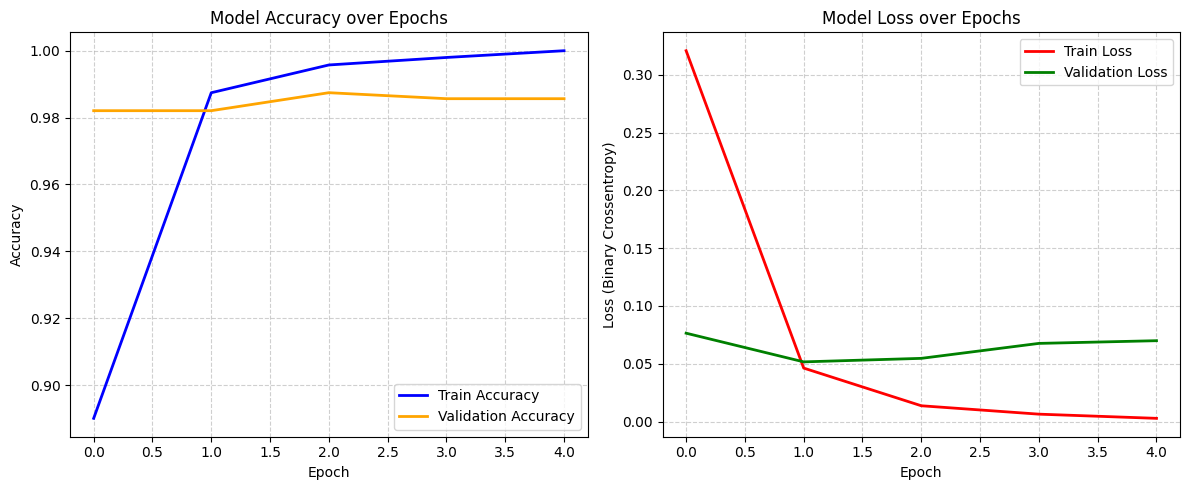

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


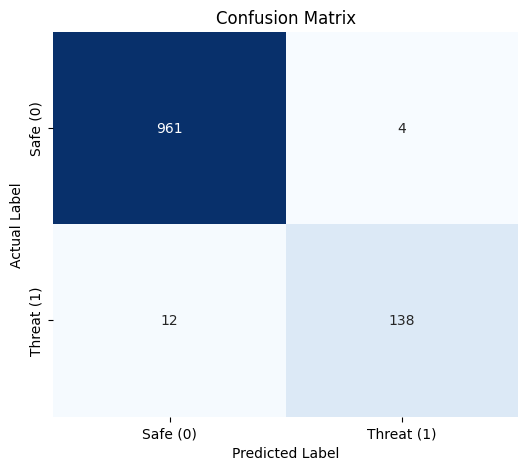


--- PERFORMANCE METRICS ---
              precision    recall  f1-score   support

    Safe (0)     0.9877    0.9959    0.9917       965
  Threat (1)     0.9718    0.9200    0.9452       150

    accuracy                         0.9857      1115
   macro avg     0.9797    0.9579    0.9685      1115
weighted avg     0.9855    0.9857    0.9855      1115



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. PLOT TRAINING AND LOSS CURVES
plt.figure(figsize=(12, 5))

# Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='green', linewidth=2)
plt.title('Model Loss over Epochs')
plt.ylabel('Loss (Binary Crossentropy)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 2. GENERATE CONFUSION MATRIX AND METRICS
# Get the model's predictions on the test set
y_pred_probs = model.predict(X_test_padded)
# Convert probabilities to binary classes (0 or 1) using the 0.50 threshold
y_pred_classes = (y_pred_probs >= 0.50).astype(int)

# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Safe (0)', 'Threat (1)'],
            yticklabels=['Safe (0)', 'Threat (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Print Performance Metrics for the Table
print("\n--- PERFORMANCE METRICS ---")
print(classification_report(y_test, y_pred_classes, target_names=['Safe (0)', 'Threat (1)'], digits=4))